# 🧭 Grid Pathfinding — Algorithm Comparison

**Problem:** Find the shortest path between two points on a 2D grid under varying obstacle configurations.

**Properties:** Discrete · Graph-based · Deterministic

**Challenge:** Evaluates path optimality, search efficiency (nodes expanded), and execution time across structurally different grid environments.

**Algorithms:** A* · BFS · Greedy Best-First · UCS · DFS

**Test cases:** Blank · Maze with loops · Obstacles · Dense · Perfect maze

---
**Run before this notebook:**
```bash
python prerun_<case>_benchmark.py   # per test case
python prerun_grid_pathfinding_analysis.py                        # all cases at once
```

## Setup and Configuration

In [63]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import seaborn as sns
import pandas as pd
from pathlib import Path
import pickle
import json
from typing import Dict, List, Tuple
import time
from IPython.display import HTML, display

# Add src to path
src_path = Path.cwd().parent
sys.path.insert(0, str(src_path))

# Import custom modules
from utils.configHelper import load_config
from experiments.prerun_grid_experiment import GridExperiment
from problems.discrete import SPProblem
from utils.visualizes.grid_visualization import (
    load_trace, create_grid_animation, plot_path_comparison,
    plot_performance_comparison, plot_convergence_comparison, display_grid
)
from utils.visualizes.grid_path_analysis import (
    analyze_path_quality, analyze_execution_time, analyze_optimality_gap, 
    print_summary_stats, analyze_nodes_expanded
)
# Set plotting style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 10)

from IPython.display import display, HTML

display(HTML("""
<style>
.output_wrapper, .output {
    height: auto !important;
    max-height: none !important;
}
</style>
"""))

print("✓ All libraries imported successfully")
print(f"✓ Working directory: {os.getcwd()}")

✓ All libraries imported successfully
✓ Working directory: D:\Uni\IT\IntroToAI\AI1_search-algorithms\src\notebooks


In [64]:
!pip install imageio-ffmpeg
import matplotlib as mpl
import imageio_ffmpeg

mpl.rcParams["animation.ffmpeg_path"] = imageio_ffmpeg.get_ffmpeg_exe()


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: C:\Users\Thong\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip


In [65]:
# Configuration
TEST_CASES = {
    'blank': 'tests/SP/blank',
    'maze_loops': 'tests/SP/maze_loops',
    'obstacles': 'tests/SP/obstacles',
    'obstacles_dense': 'tests/SP/obstacles_dense',
    'perfect_maze': 'tests/SP/perfect_maze'
}

# Algorithms to test (excluding metaheuristics)
ALGORITHMS = ['DFS', 'BFS', 'GreedyBestFirst', 'AStarSearch', 'GA_Grid', 'ACO_Grid']
ALGORITHMS_DISPLAY = ['DFS', 'BFS/Uniform Cost', 'Greedy Best-First', 'A*', 'Genetic Algorithm', 'ACO']

# Output directory
OUTPUT_DIR = Path('outputs/grid_analysis')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Test cases: {list(TEST_CASES.keys())}")
print(f"Algorithms: {ALGORITHMS}")
print(f"Output directory: {OUTPUT_DIR}")

Test cases: ['blank', 'maze_loops', 'obstacles', 'obstacles_dense', 'perfect_maze']
Algorithms: ['DFS', 'BFS', 'GreedyBestFirst', 'AStarSearch', 'GA_Grid', 'ACO_Grid']
Output directory: outputs\grid_analysis


In [66]:
from pathlib import Path

# locate project root
PROJECT_ROOT = Path.cwd().parents[1]

# correct output folder
OUTPUT_DIR = PROJECT_ROOT / "src" / "outputs" / "grid_analysis"

print("Output directory:", OUTPUT_DIR)

Output directory: D:\Uni\IT\IntroToAI\AI1_search-algorithms\src\outputs\grid_analysis


In [67]:
# Load and display benchmark results for each case
benchmark_results = {}

for case_name in TEST_CASES.keys():

    csv_path = OUTPUT_DIR / f"{case_name}_benchmark.csv"

    if csv_path.exists():
        df = pd.read_csv(csv_path)
        benchmark_results[case_name] = df
        print(f"✓ Loaded {case_name}: {len(df)} results")

    else:
        print(f"✗ Benchmark CSV not found: {csv_path}")
        print(f"  Please run: python {OUTPUT_DIR}/prerun_{case_name}_benchmark.py")

✓ Loaded blank: 60 results
✓ Loaded maze_loops: 120 results
✓ Loaded obstacles: 120 results
✓ Loaded obstacles_dense: 120 results
✓ Loaded perfect_maze: 120 results


### Blank Grid - Test Case 1

In [ ]:
from pathlib import Path
import numpy as np

# Define project root (AI1_search-algorithms)
PROJECT_ROOT = Path.cwd().parents[1]

# Load blank test_0.txt
case_name = 'blank'
test_file = PROJECT_ROOT / "src" / "tests" / "SP" / case_name / "test_0.txt"

print(f"Loading {case_name} case...")
print(f"File path: {test_file}")

# Safety check
if not test_file.exists():
    raise FileNotFoundError(f"Test file not found: {test_file}")

problem = SPProblem(str(test_file))

print(f"✓ Grid: {problem.n} × {problem.m}")
print(f"  Obstacles: {np.sum(problem.grid == 1)}")

# Display grid
fig = display_grid(
    problem.grid,
    problem.start_node,
    problem.end_node,
    title=f"Grid - {case_name}",
    figsize=(6,6)
)
# Save output
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

plt.savefig(OUTPUT_DIR / f"{case_name}_grid.png", dpi=100, bbox_inches="tight")
plt.show()

In [ ]:
# Run algorithms
print(f"Running algorithms on {case_name}...")
experiment = GridExperiment(problem)

start_time = time.time()
trace = experiment.visualize(ALGORITHMS, trace_path='blank_trace.pkl')
elapsed = time.time() - start_time

print(f"✓ Completed in {elapsed:.2f}s\n")
# print("Results:")
# for algo_name in ALGORITHMS:
#     if algo_name in trace['algorithms']:
#         result = trace['algorithms'][algo_name]
#         path_len = result.get('path_length', 'Failed')
#         nodes_exp = result.get('nodes_expanded', 'N/A')
#         time_t = result.get('execution_time_seconds', 'N/A')
#         print(f"  {algo_name:20s} - Path: {path_len:4} | Nodes: {nodes_exp:6} | Time: {time_t:.4f}s")

In [ ]:
%matplotlib inline
from pathlib import Path

OUTPUT_DIR = Path("outputs")

animations = {
    "BFS": "bfs_blank.mp4",
    "AStarSearch": "astar_blank.mp4",
    "DFS": "dfs_blank.mp4",
    "GreedyBestFirst": "greedy_blank.mp4",
}

for algo, filename in animations.items():
    save_path = OUTPUT_DIR / filename

    if save_path.exists():
        print(f"✓ {filename} already exists, skipping...")
        continue

    print(f"Creating expansion animation for {algo}...")
    create_grid_animation(trace, algo, interval=20, save_path=str(save_path))

In [ ]:
from IPython.display import Video

HTML("""
<div style="display:grid; grid-template-columns: 1fr 1fr; gap:20px; width:700px">

<div>
<p style="text-align:center"><b>BFS/UCS</b></p>
<video width="320" controls>
  <source src="outputs/bfs_blank.mp4" type="video/mp4">
</video>
</div>

<div>
<p style="text-align:center"><b>A*</b></p>
<video width="320" controls>
  <source src="outputs/astar_blank.mp4" type="video/mp4">
</video>
</div>

<div>
<p style="text-align:center"><b>DFS</b></p>
<video width="320" controls>
  <source src="outputs/dfs_blank.mp4" type="video/mp4">
</video>
</div>

<div>
<p style="text-align:center"><b>Greedy Best-First Search</b></p>
<video width="320" controls>
  <source src="outputs/greedy_blank.mp4" type="video/mp4">
</video>
</div>

</div>
""")

In [ ]:
# Path comparison
fig = plot_path_comparison(trace, ALGORITHMS)
plt.savefig(OUTPUT_DIR / f'{case_name}_paths.png', dpi=150, bbox_inches='tight')
plt.show()

# Save trace
trace_file = OUTPUT_DIR / f'{case_name}_stage1_trace.pkl'
with open(trace_file, 'wb') as f:
    pickle.dump(trace, f)
print(f"Saved trace to {trace_file}")

In [ ]:
case_name = 'blank'
if case_name in benchmark_results:
    df = benchmark_results[case_name]
    
    fig = analyze_path_quality(df, case_name)
    plt.savefig(OUTPUT_DIR / f'{case_name}_pathlen_performance.png', dpi=150, bbox_inches='tight')
    plt.show()

    fig = analyze_execution_time(df, case_name)
    plt.savefig(OUTPUT_DIR / f'{case_name}_execution_time.png', dpi=150, bbox_inches='tight')
    plt.show()

    # fig = analyze_optimality_gap(df, case_name)
    # plt.savefig(OUTPUT_DIR / f'{case_name}_.png', dpi=150, bbox_inches='tight')
    # plt.show()

    fig = analyze_nodes_expanded(df, case_name)
    plt.savefig(OUTPUT_DIR / f'{case_name}_nodes_expanded.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print_summary_stats(df, case_name)
else:
    print(f"Benchmark data not available for {case_name}")

### maze_loops - Test Case 2

In [ ]:
from pathlib import Path
import numpy as np

# Define project root (AI1_search-algorithms)
PROJECT_ROOT = Path.cwd().parents[1]

# Load blank test_0.txt
case_name = 'maze_loops'
test_file = PROJECT_ROOT / "src" / "tests" / "SP" / case_name / "test_0.txt"

print(f"Loading {case_name} case...")
print(f"File path: {test_file}")

# Safety check
if not test_file.exists():
    raise FileNotFoundError(f"Test file not found: {test_file}")

problem = SPProblem(str(test_file))

print(f"✓ Grid: {problem.n} × {problem.m}")
print(f"  Obstacles: {np.sum(problem.grid == 1)}")

# Display grid
fig = display_grid(
    problem.grid,
    problem.start_node,
    problem.end_node,
    title=f"Grid - {case_name}",
    figsize=(6,6)
)
# Save output
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

plt.savefig(OUTPUT_DIR / f"{case_name}_grid.png", dpi=100, bbox_inches="tight")
plt.show()

In [ ]:
# Run algorithms
print(f"Running algorithms on {case_name}...")
experiment = GridExperiment(problem)

start_time = time.time()
trace = experiment.visualize(ALGORITHMS, trace_path='maze_loops_trace.pkl')
elapsed = time.time() - start_time

print(f"✓ Completed in {elapsed:.2f}s\n")
# print("Results:")
# for algo_name in ALGORITHMS:
#     if algo_name in trace['algorithms']:
#         result = trace['algorithms'][algo_name]
#         path_len = result.get('path_length', 'Failed')
#         nodes_exp = result.get('nodes_expanded', 'N/A')
#         time_t = result.get('execution_time_seconds', 'N/A')
#         print(f"  {algo_name:20s} - Path: {path_len:4} | Nodes: {nodes_exp:6} | Time: {time_t:.4f}s")

In [ ]:
%matplotlib inline
from pathlib import Path

OUTPUT_DIR = Path("outputs")

animations = {
    "BFS": "bfs_maze_loops.mp4",
    "AStarSearch": "astar_maze_loops.mp4",
    "DFS": "dfs_maze_loops.mp4",
    "GreedyBestFirst": "greedy_maze_loops.mp4",
}

for algo, filename in animations.items():
    save_path = OUTPUT_DIR / filename

    if save_path.exists():
        print(f"✓ {filename} already exists, skipping...")
        continue

    print(f"Creating expansion animation for {algo}...")
    create_grid_animation(trace, algo, interval=20, save_path=str(save_path))

In [ ]:
from IPython.display import Video

HTML("""
<div style="display:grid; grid-template-columns: 1fr 1fr; gap:20px; width:700px">

<div>
<p style="text-align:center"><b>BFS/UCS</b></p>
<video width="320" controls>
  <source src="outputs/bfs_maze_loops.mp4" type="video/mp4">
</video>
</div>

<div>
<p style="text-align:center"><b>A*</b></p>
<video width="320" controls>
  <source src="outputs/astar_maze_loops.mp4" type="video/mp4">
</video>
</div>

<div>
<p style="text-align:center"><b>DFS</b></p>
<video width="320" controls>
  <source src="outputs/dfs_maze_loops.mp4" type="video/mp4">
</video>
</div>

<div>
<p style="text-align:center"><b>Greedy Best-First Search</b></p>
<video width="320" controls>
  <source src="outputs/greedy_maze_loops.mp4" type="video/mp4">
</video>
</div>

</div>
""")

In [ ]:
# Path comparison
fig = plot_path_comparison(trace, ALGORITHMS)
plt.savefig(OUTPUT_DIR / f'{case_name}_paths.png', dpi=150, bbox_inches='tight')
plt.show()

# Save trace
trace_file = OUTPUT_DIR / f'{case_name}_stage1_trace.pkl'
with open(trace_file, 'wb') as f:
    pickle.dump(trace, f)
print(f"Saved trace to {trace_file}")

In [ ]:
case_name = 'maze_loops'
if case_name in benchmark_results:
    df = benchmark_results[case_name]
    
    fig = analyze_path_quality(df, case_name)
    plt.savefig(OUTPUT_DIR / f'{case_name}_pathlen_performance.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    fig = analyze_execution_time(df, case_name)
    plt.savefig(OUTPUT_DIR / f'{case_name}_execution_time.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    fig = analyze_nodes_expanded(df, case_name)
    plt.savefig(OUTPUT_DIR / f'{case_name}_nodes_expanded.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print_summary_stats(df, case_name)
else:
    print(f"Benchmark data not available for {case_name}")

### obstacles - Test Case 3

Loading obstacles case...
File path: D:\Uni\IT\IntroToAI\AI1_search-algorithms\src\tests\SP\obstacles\test_0.txt
✓ Grid: 40 × 40
  Obstacles: 443


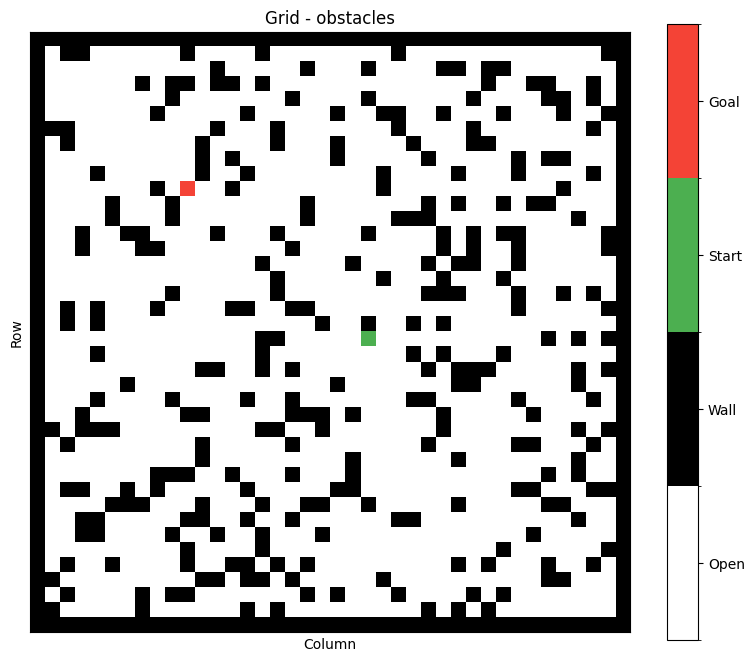

<Figure size 1400x1000 with 0 Axes>

In [69]:
from pathlib import Path
import numpy as np

# Define project directories
PROJECT_ROOT = Path.cwd().parents[1]
TEST_DIR = PROJECT_ROOT / "src" / "tests" / "SP"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

# Load obstacles test
case_name = 'obstacles'
test_file = TEST_DIR / case_name / "test_0.txt"

print(f"Loading {case_name} case...")
print(f"File path: {test_file}")

if not test_file.exists():
    raise FileNotFoundError(f"Test file not found: {test_file}")

problem = SPProblem(str(test_file))

print(f"✓ Grid: {problem.n} × {problem.m}")
print(f"  Obstacles: {np.sum(problem.grid == 1)}")

# Display grid
fig = display_grid(
    problem.grid,
    problem.start_node,
    problem.end_node,
    title=f"Grid - {case_name}"
)

plt.savefig(OUTPUT_DIR / f"{case_name}_paths.png", dpi=150, bbox_inches="tight")
plt.show()

In [70]:
# Run algorithms
print(f"Running algorithms on {case_name}...")
experiment = GridExperiment(problem)

start_time = time.time()
trace = experiment.visualize(ALGORITHMS, trace_path='obstacles_trace.pkl')
elapsed = time.time() - start_time

print(f"✓ Completed in {elapsed:.2f}s\n")
# print("Results:")
# for algo_name in ALGORITHMS:
#     if algo_name in trace['algorithms']:
#         result = trace['algorithms'][algo_name]
#         path_len = result.get('path_length', 'Failed')
#         nodes_exp = result.get('nodes_expanded', 'N/A')
#         time_t = result.get('execution_time_seconds', 'N/A')
#         print(f"  {algo_name:20s} - Path: {path_len:4} | Nodes: {nodes_exp:6} | Time: {time_t:.4f}s")

Running algorithms on obstacles...
Running visual experiment on 40x40 grid...
Running DFS...
  ✓ DFS completed
Running BFS...
  ✓ BFS completed
Running GreedyBestFirst...
  ✓ GreedyBestFirst completed
Running AStarSearch...
  ✓ AStarSearch completed
Running GA_Grid...
  ✓ GA_Grid completed
Running ACO_Grid...
  ✓ ACO_Grid completed
Trace saved to: obstacles_trace.pkl
✓ Completed in 0.33s



In [71]:
%matplotlib inline
from pathlib import Path

OUTPUT_DIR = Path("outputs")

animations = {
    "BFS": "bfs_obstacles.mp4",
    "AStarSearch": "astar_obstacles.mp4",
    "DFS": "dfs_obstacles.mp4",
    "GreedyBestFirst": "greedy_obstacles.mp4",
}

for algo, filename in animations.items():
    save_path = OUTPUT_DIR / filename

    if save_path.exists():
        print(f"✓ {filename} already exists, skipping...")
        continue

    print(f"Creating expansion animation for {algo}...")
    create_grid_animation(trace, algo, interval=20, save_path=str(save_path))

✓ bfs_obstacles.mp4 already exists, skipping...
✓ astar_obstacles.mp4 already exists, skipping...
✓ dfs_obstacles.mp4 already exists, skipping...
✓ greedy_obstacles.mp4 already exists, skipping...


In [72]:
from IPython.display import Video

HTML("""
<div style="display:grid; grid-template-columns: 1fr 1fr; gap:20px; width:700px">

<div>
<p style="text-align:center"><b>BFS/UCS</b></p>
<video width="320" controls>
  <source src="outputs/bfs_obstacles.mp4" type="video/mp4">
</video>
</div>

<div>
<p style="text-align:center"><b>A*</b></p>
<video width="320" controls>
  <source src="outputs/astar_obstacles.mp4" type="video/mp4">
</video>
</div>

<div>
<p style="text-align:center"><b>DFS</b></p>
<video width="320" controls>
  <source src="outputs/dfs_obstacles.mp4" type="video/mp4">
</video>
</div>

<div>
<p style="text-align:center"><b>Greedy Best-First Search</b></p>
<video width="320" controls>
  <source src="outputs/greedy_obstacles.mp4" type="video/mp4">
</video>
</div>

</div>
""")

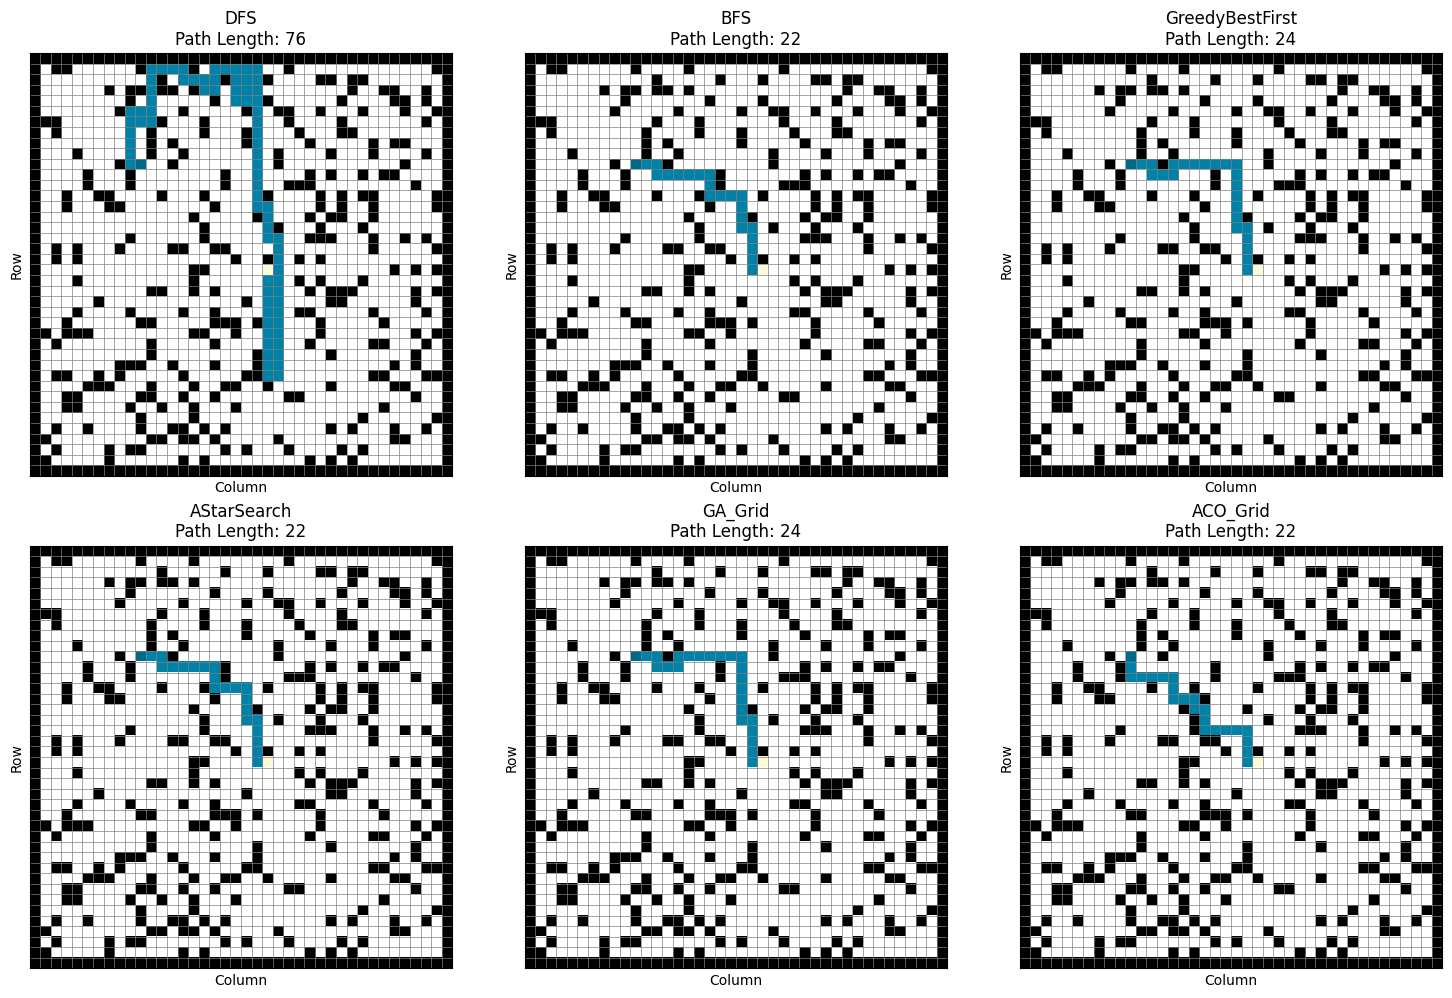

Saved trace to outputs\obstacles_stage1_trace.pkl


In [73]:
# Path comparison
fig = plot_path_comparison(trace, ALGORITHMS)
plt.savefig(OUTPUT_DIR / f'{case_name}_paths.png', dpi=150, bbox_inches='tight')
plt.show()

# Save trace
trace_file = OUTPUT_DIR / f'{case_name}_stage1_trace.pkl'
with open(trace_file, 'wb') as f:
    pickle.dump(trace, f)
print(f"Saved trace to {trace_file}")

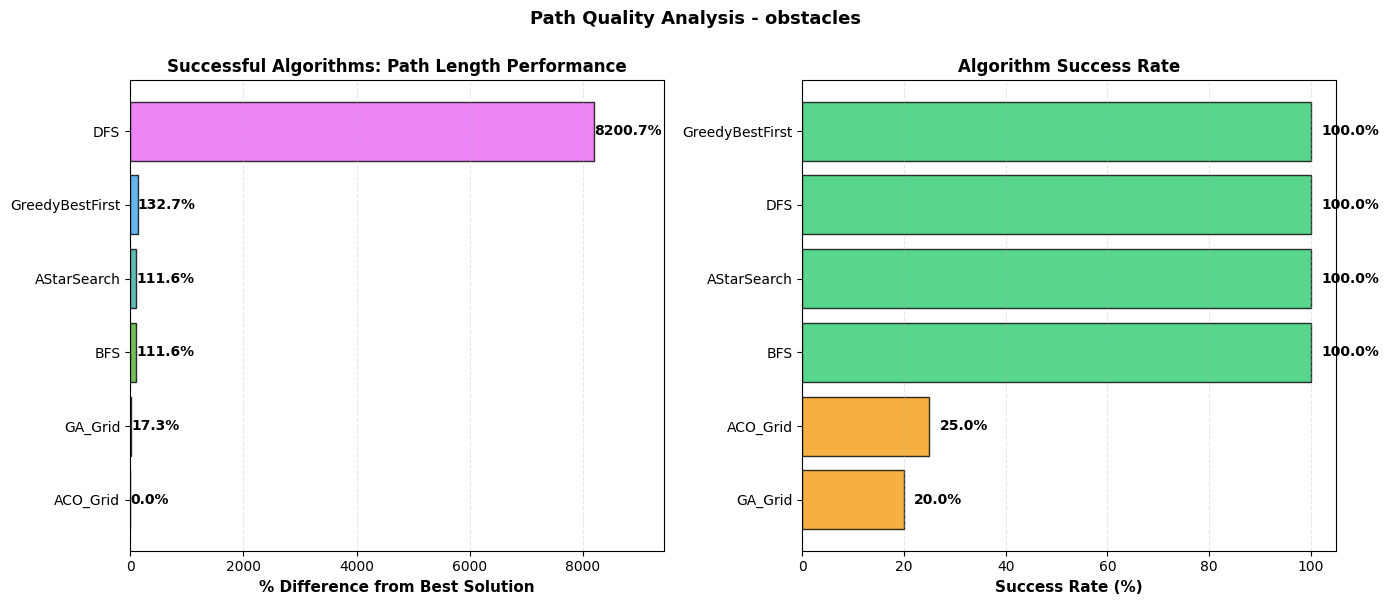

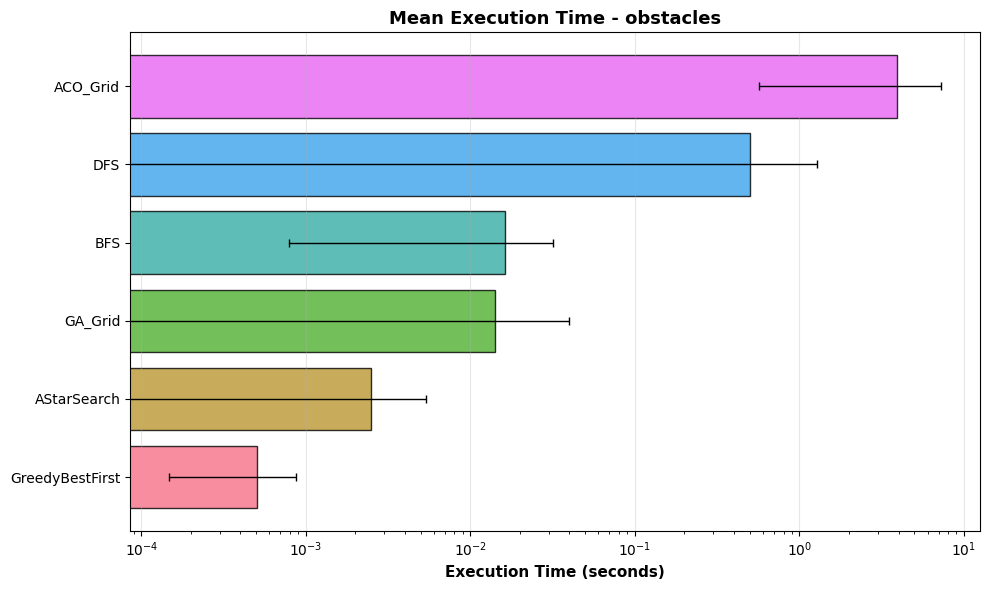

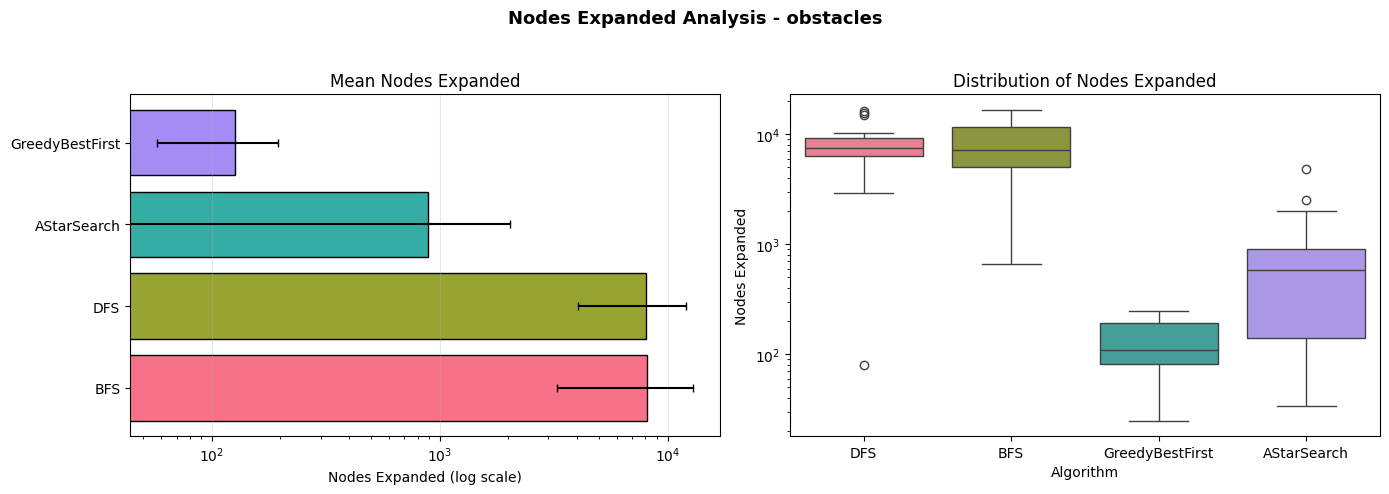


                         OBSTACLES - SUMMARY STATISTICS                         

OVERALL PERFORMANCE:
--------------------------------------------------------------------------------
                 Total Runs  Successful  Mean Path  Best Path  Mean Time  \
algorithm                                                                  
ACO_Grid                 20           5        inf       22.0     3.9241   
AStarSearch              20          20     103.25       22.0     0.0025   
BFS                      20          20     103.25       22.0     0.0163   
DFS                      20          20    4050.75       76.0     0.4997   
GA_Grid                  20           4        inf       24.0     0.0141   
GreedyBestFirst          20          20     113.55       24.0     0.0005   

                 Std Time  Success Rate %  
algorithm                                  
ACO_Grid           3.3600            25.0  
AStarSearch        0.0029           100.0  
BFS                0.0156     

In [75]:
case_name = 'obstacles'
if case_name in benchmark_results:
    df = benchmark_results[case_name]
    
    fig = analyze_path_quality(df, case_name)
    plt.savefig(OUTPUT_DIR / f'{case_name}_pathlen_performance.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    fig = analyze_execution_time(df, case_name)
    plt.savefig(OUTPUT_DIR / f'{case_name}_execution_time.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    fig = analyze_nodes_expanded(df, case_name)
    plt.savefig(OUTPUT_DIR / f'{case_name}_nodes_expanded.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print_summary_stats(df, case_name)
else:
    print(f"Benchmark data not available for {case_name}")

### dense - Test Case 4

Loading obstacles_dense case...
File path: D:\Uni\IT\IntroToAI\AI1_search-algorithms\src\tests\SP\obstacles_dense\test_0.txt
✓ Grid: 40 × 40
  Obstacles: 675


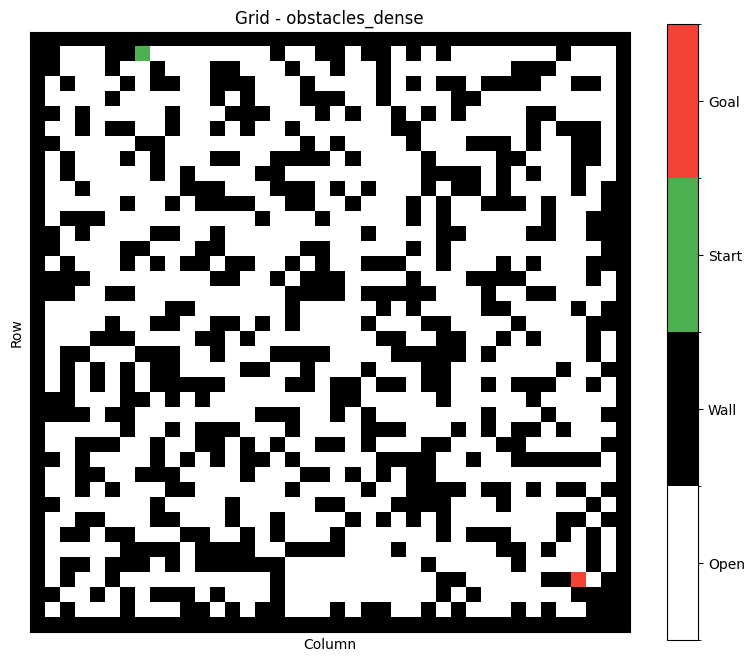

<Figure size 1400x1000 with 0 Axes>

<Figure size 1400x1000 with 0 Axes>

In [76]:
from pathlib import Path
import numpy as np

# Define project directories
PROJECT_ROOT = Path.cwd().parents[1]
TEST_DIR = PROJECT_ROOT / "src" / "tests" / "SP"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

# Load dense test
case_name = 'obstacles_dense'
test_file = TEST_DIR / case_name / "test_0.txt"

print(f"Loading {case_name} case...")
print(f"File path: {test_file}")

if not test_file.exists():
    raise FileNotFoundError(f"Test file not found: {test_file}")

problem = SPProblem(str(test_file))

print(f"✓ Grid: {problem.n} × {problem.m}")
print(f"  Obstacles: {np.sum(problem.grid == 1)}")

# Display grid
fig = display_grid(
    problem.grid,
    problem.start_node,
    problem.end_node,
    title=f"Grid - {case_name}"
)

plt.savefig(OUTPUT_DIR / f"{case_name}_grid.png", dpi=150, bbox_inches="tight")
plt.show()

plt.savefig(OUTPUT_DIR / f"{case_name}_paths.png", dpi=150, bbox_inches="tight")
plt.show()

In [77]:
# Run algorithms
print(f"Running algorithms on {case_name}...")
experiment = GridExperiment(problem)

start_time = time.time()
trace = experiment.visualize(ALGORITHMS, trace_path='obstacles_dense_trace.pkl')
elapsed = time.time() - start_time

print(f"✓ Completed in {elapsed:.2f}s\n")
# print("Results:")
# for algo_name in ALGORITHMS:
#     if algo_name in trace['algorithms']:
#         result = trace['algorithms'][algo_name]
#         path_len = result.get('path_length', 'Failed')
#         nodes_exp = result.get('nodes_expanded', 'N/A')
#         time_t = result.get('execution_time_seconds', 'N/A')
#         print(f"  {algo_name:20s} - Path: {path_len:4} | Nodes: {nodes_exp:6} | Time: {time_t:.4f}s")

Running algorithms on obstacles_dense...
Running visual experiment on 40x40 grid...
Running DFS...
  ✓ DFS completed
Running BFS...
  ✓ BFS completed
Running GreedyBestFirst...
  ✓ GreedyBestFirst completed
Running AStarSearch...
  ✓ AStarSearch completed
Running GA_Grid...
  ✓ GA_Grid completed
Running ACO_Grid...
  ✓ ACO_Grid completed
Trace saved to: obstacles_dense_trace.pkl
✓ Completed in 6.20s



In [78]:
%matplotlib inline
from pathlib import Path

OUTPUT_DIR = Path("outputs")

animations = {
    "BFS": "bfs_obstacles_dense.mp4",
    "AStarSearch": "astar_obstacles_dense.mp4",
    "DFS": "dfs_obstacles_dense.mp4",
    "GreedyBestFirst": "greedy_obstacles_dense.mp4",
}

for algo, filename in animations.items():
    save_path = OUTPUT_DIR / filename

    if save_path.exists():
        print(f"✓ {filename} already exists, skipping...")
        continue

    print(f"Creating expansion animation for {algo}...")
    create_grid_animation(trace, algo, interval=20, save_path=str(save_path))

✓ bfs_obstacles_dense.mp4 already exists, skipping...
✓ astar_obstacles_dense.mp4 already exists, skipping...
✓ dfs_obstacles_dense.mp4 already exists, skipping...
✓ greedy_obstacles_dense.mp4 already exists, skipping...


In [79]:
from IPython.display import Video

HTML("""
<div style="display:grid; grid-template-columns: 1fr 1fr; gap:20px; width:700px">

<div>
<p style="text-align:center"><b>BFS/UCS</b></p>
<video width="320" controls>
  <source src="outputs/bfs_obstacles_dense.mp4" type="video/mp4">
</video>
</div>

<div>
<p style="text-align:center"><b>A*</b></p>
<video width="320" controls>
  <source src="outputs/astar_obstacles_dense.mp4" type="video/mp4">
</video>
</div>

<div>
<p style="text-align:center"><b>DFS</b></p>
<video width="320" controls>
  <source src="outputs/dfs_obstacles_dense.mp4" type="video/mp4">
</video>
</div>

<div>
<p style="text-align:center"><b>Greedy Best-First Search</b></p>
<video width="320" controls>
  <source src="outputs/greedy_obstacles_dense.mp4" type="video/mp4">
</video>
</div>

</div>
""")

TypeError: 'NoneType' object is not iterable

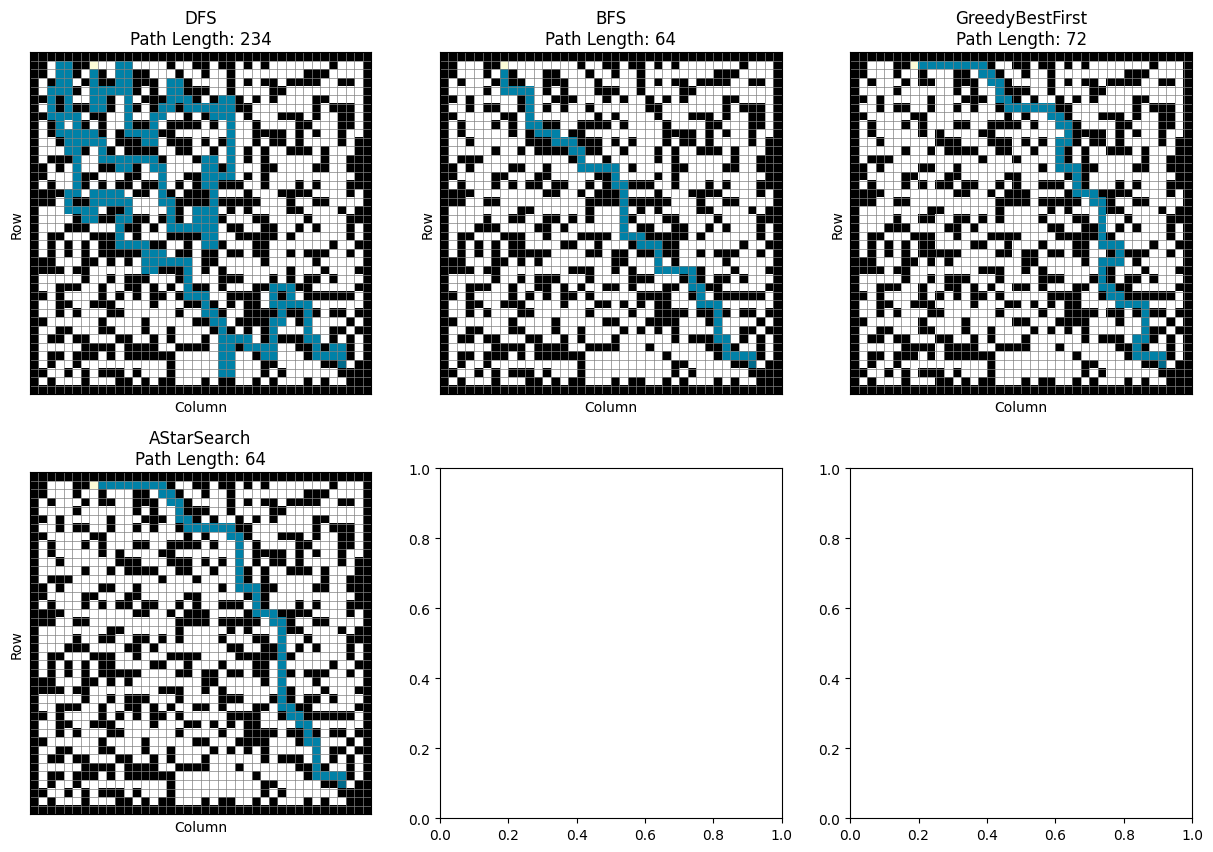

In [80]:
# Path comparison
fig = plot_path_comparison(trace, ALGORITHMS)
plt.savefig(OUTPUT_DIR / f'{case_name}_paths.png', dpi=150, bbox_inches='tight')
plt.show()

# Save trace
trace_file = OUTPUT_DIR / f'{case_name}_stage1_trace.pkl'
with open(trace_file, 'wb') as f:
    pickle.dump(trace, f)
print(f"Saved trace to {trace_file}")

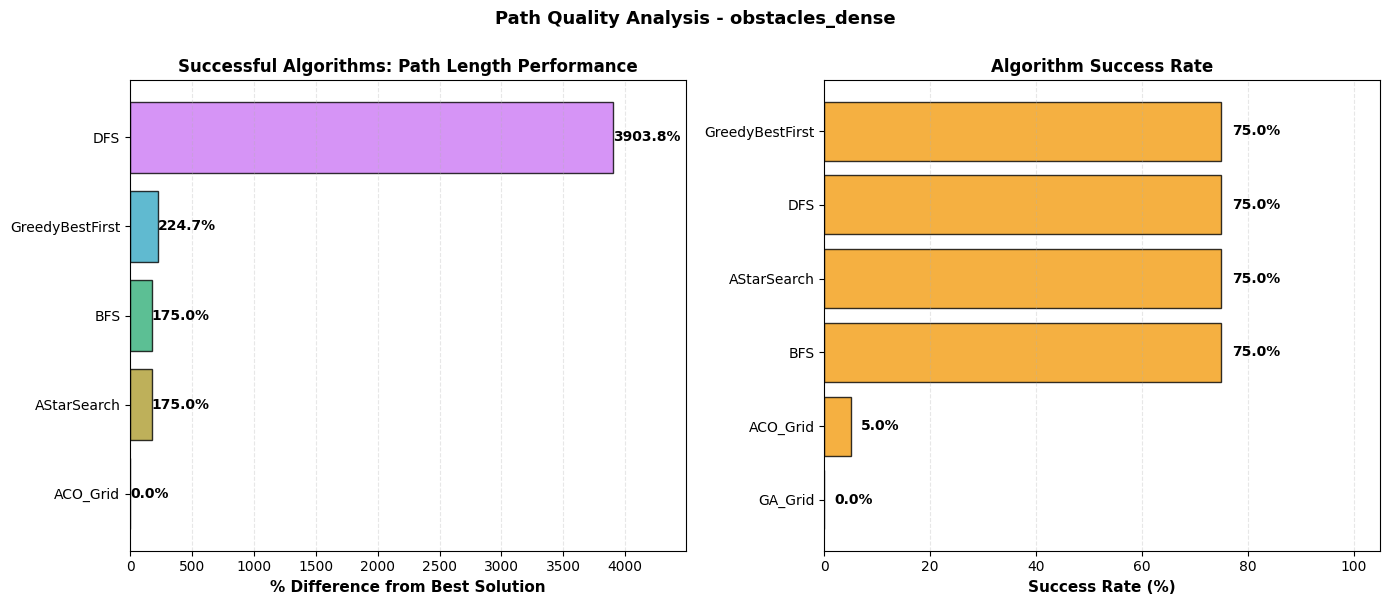

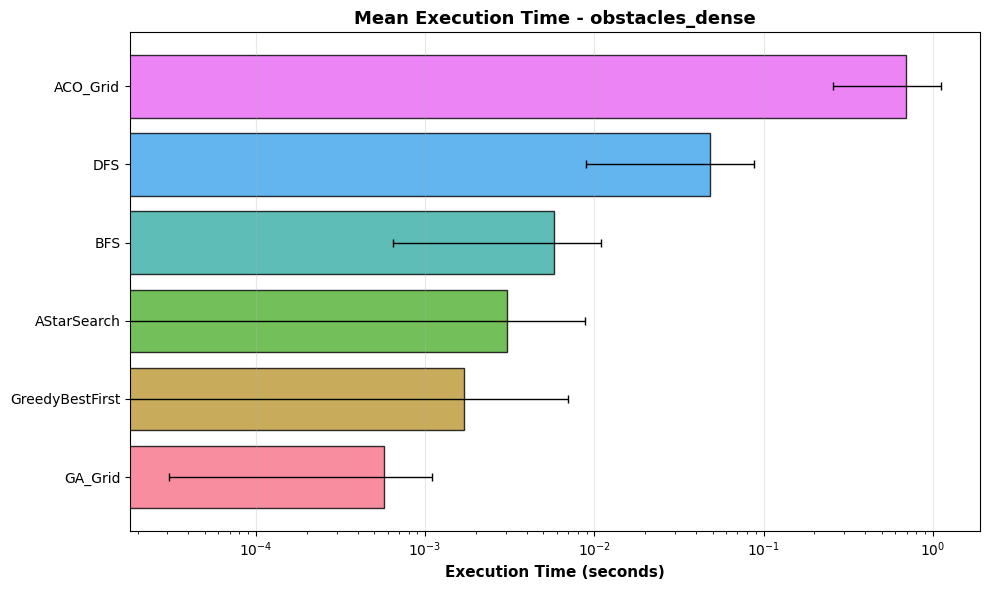

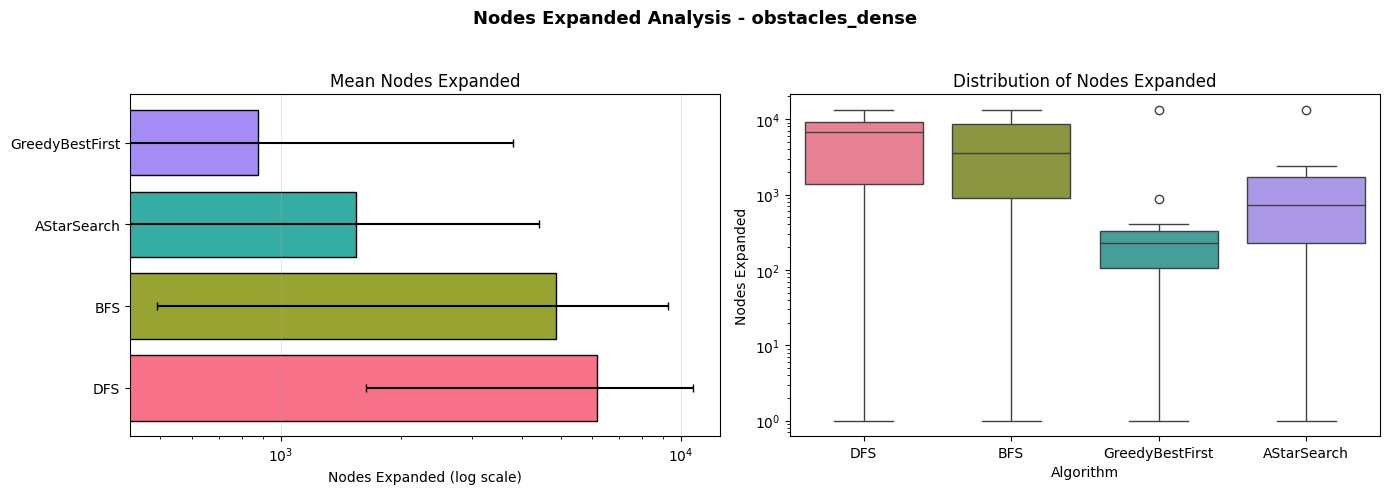


                      OBSTACLES_DENSE - SUMMARY STATISTICS                      

OVERALL PERFORMANCE:
--------------------------------------------------------------------------------
                 Total Runs  Successful  Mean Path  Best Path  Mean Time  \
algorithm                                                                  
ACO_Grid                 20           1        inf       44.0     0.6912   
AStarSearch              20          15        inf       38.0     0.0030   
BFS                      20          15        inf       38.0     0.0058   
DFS                      20          15        inf      234.0     0.0481   
GA_Grid                  20           0        inf        inf     0.0006   
GreedyBestFirst          20          15        inf       54.0     0.0017   

                 Std Time  Success Rate %  
algorithm                                  
ACO_Grid           0.4335             5.0  
AStarSearch        0.0058            75.0  
BFS                0.0051     

In [81]:
case_name = 'obstacles_dense'
if case_name in benchmark_results:
    df = benchmark_results[case_name]
    
    fig = analyze_path_quality(df, case_name)
    plt.savefig(OUTPUT_DIR / f'{case_name}_pathlen_performance.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    fig = analyze_execution_time(df, case_name)
    plt.savefig(OUTPUT_DIR / f'{case_name}_execution_time.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    fig = analyze_nodes_expanded(df, case_name)
    plt.savefig(OUTPUT_DIR / f'{case_name}_nodes_expanded.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print_summary_stats(df, case_name)
else:
    print(f"Benchmark data not available for {case_name}")

### perfect_maze - Test Case 5

Loading perfect_maze case...
File path: D:\Uni\IT\IntroToAI\AI1_search-algorithms\src\tests\SP\perfect_maze\test_0.txt
✓ Grid: 41 × 41
  Obstacles: 882


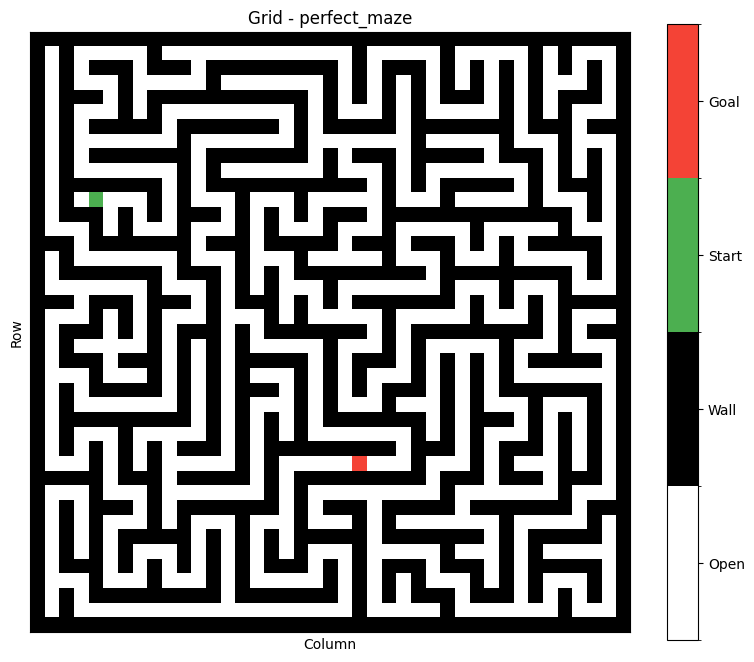

<Figure size 1400x1000 with 0 Axes>

<Figure size 1400x1000 with 0 Axes>

In [82]:
from pathlib import Path
import numpy as np

# Define project directories
PROJECT_ROOT = Path.cwd().parents[1]
TEST_DIR = PROJECT_ROOT / "src" / "tests" / "SP"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

# Load perfect_maze test
case_name = 'perfect_maze'
test_file = TEST_DIR / case_name / "test_0.txt"

print(f"Loading {case_name} case...")
print(f"File path: {test_file}")

if not test_file.exists():
    raise FileNotFoundError(f"Test file not found: {test_file}")

problem = SPProblem(str(test_file))

print(f"✓ Grid: {problem.n} × {problem.m}")
print(f"  Obstacles: {np.sum(problem.grid == 1)}")

# Display grid
fig = display_grid(
    problem.grid,
    problem.start_node,
    problem.end_node,
    title=f"Grid - {case_name}"
)

plt.savefig(OUTPUT_DIR / f"{case_name}_grid.png", dpi=150, bbox_inches="tight")
plt.show()

plt.savefig(OUTPUT_DIR / f"{case_name}_paths.png", dpi=150, bbox_inches="tight")
plt.show()

In [83]:
# Run algorithms
print(f"Running algorithms on {case_name}...")
experiment = GridExperiment(problem)

start_time = time.time()
trace = experiment.visualize(ALGORITHMS, trace_path='perfect_maze_trace.pkl')
elapsed = time.time() - start_time

print(f"✓ Completed in {elapsed:.2f}s\n")
# print("Results:")
# for algo_name in ALGORITHMS:
#     if algo_name in trace['algorithms']:
#         result = trace['algorithms'][algo_name]
#         path_len = result.get('path_length', 'Failed')
#         nodes_exp = result.get('nodes_expanded', 'N/A')
#         time_t = result.get('execution_time_seconds', 'N/A')
#         print(f"  {algo_name:20s} - Path: {path_len:4} | Nodes: {nodes_exp:6} | Time: {time_t:.4f}s")

Running algorithms on perfect_maze...
Running visual experiment on 41x41 grid...
Running DFS...
  ✓ DFS completed
Running BFS...
  ✓ BFS completed
Running GreedyBestFirst...
  ✓ GreedyBestFirst completed
Running AStarSearch...
  ✓ AStarSearch completed
Running GA_Grid...
  ✓ GA_Grid completed
Running ACO_Grid...
  ✓ ACO_Grid completed
Trace saved to: perfect_maze_trace.pkl
✓ Completed in 0.72s



In [84]:
%matplotlib inline
from pathlib import Path

OUTPUT_DIR = Path("outputs")

animations = {
    "BFS": "bfs_perfect_maze.mp4",
    "AStarSearch": "astar_perfect_maze.mp4",
    "DFS": "dfs_perfect_maze.mp4",
    "GreedyBestFirst": "greedy_perfect_maze.mp4",
}

for algo, filename in animations.items():
    save_path = OUTPUT_DIR / filename

    if save_path.exists():
        print(f"✓ {filename} already exists, skipping...")
        continue

    print(f"Creating expansion animation for {algo}...")
    create_grid_animation(trace, algo, interval=20, save_path=str(save_path))

✓ bfs_perfect_maze.mp4 already exists, skipping...
✓ astar_perfect_maze.mp4 already exists, skipping...
✓ dfs_perfect_maze.mp4 already exists, skipping...
✓ greedy_perfect_maze.mp4 already exists, skipping...


In [85]:
from IPython.display import Video

HTML("""
<div style="display:grid; grid-template-columns: 1fr 1fr; gap:20px; width:700px">

<div>
<p style="text-align:center"><b>BFS/UCS</b></p>
<video width="320" controls>
  <source src="outputs/bfs_perfect_maze.mp4" type="video/mp4">
</video>
</div>

<div>
<p style="text-align:center"><b>A*</b></p>
<video width="320" controls>
  <source src="outputs/astar_perfect_maze.mp4" type="video/mp4">
</video>
</div>

<div>
<p style="text-align:center"><b>DFS</b></p>
<video width="320" controls>
  <source src="outputs/dfs_perfect_maze.mp4" type="video/mp4">
</video>
</div>

<div>
<p style="text-align:center"><b>Greedy Best-First Search</b></p>
<video width="320" controls>
  <source src="outputs/greedy_perfect_maze.mp4" type="video/mp4">
</video>
</div>

</div>
""")

TypeError: 'NoneType' object is not iterable

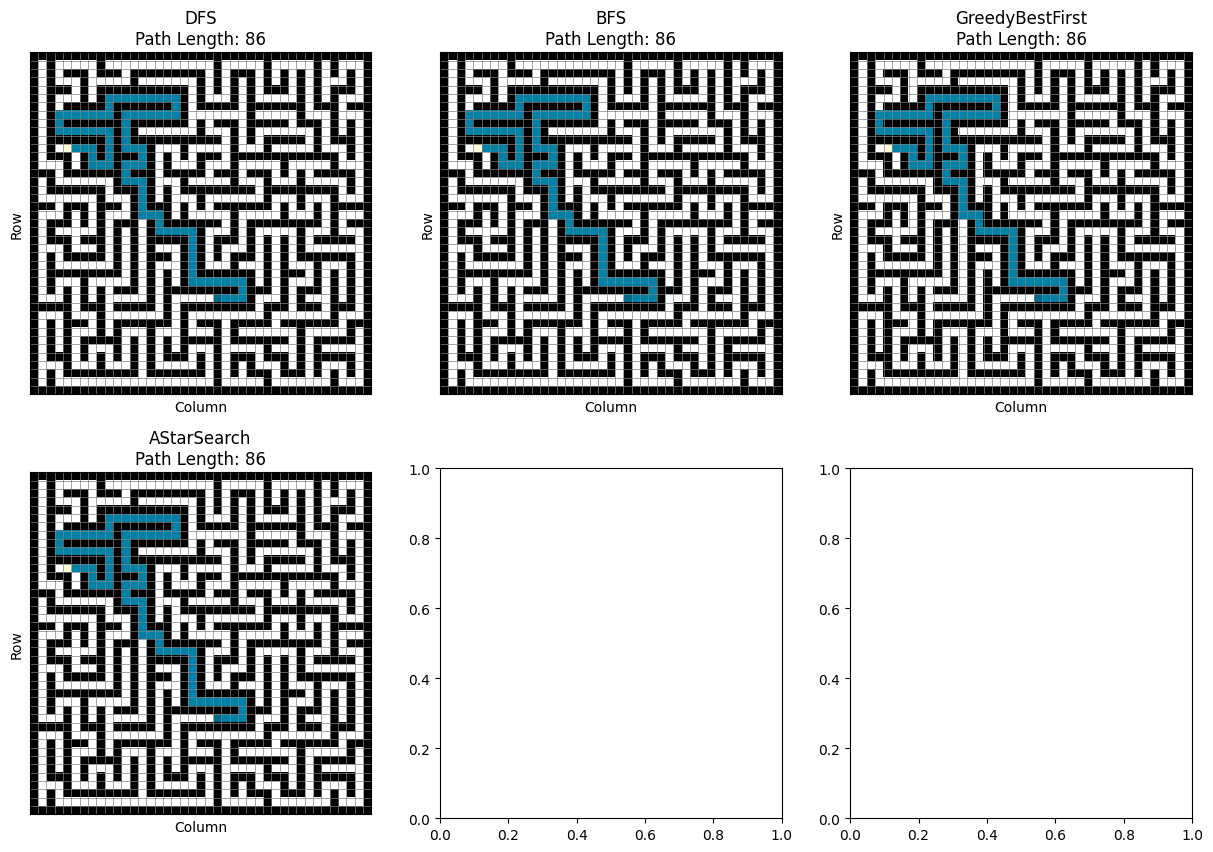

In [86]:
# Path comparison
fig = plot_path_comparison(trace, ALGORITHMS)
plt.savefig(OUTPUT_DIR / f'{case_name}_paths.png', dpi=150, bbox_inches='tight')
plt.show()

# Save trace
trace_file = OUTPUT_DIR / f'{case_name}_stage1_trace.pkl'
with open(trace_file, 'wb') as f:
    pickle.dump(trace, f)
print(f"Saved trace to {trace_file}")

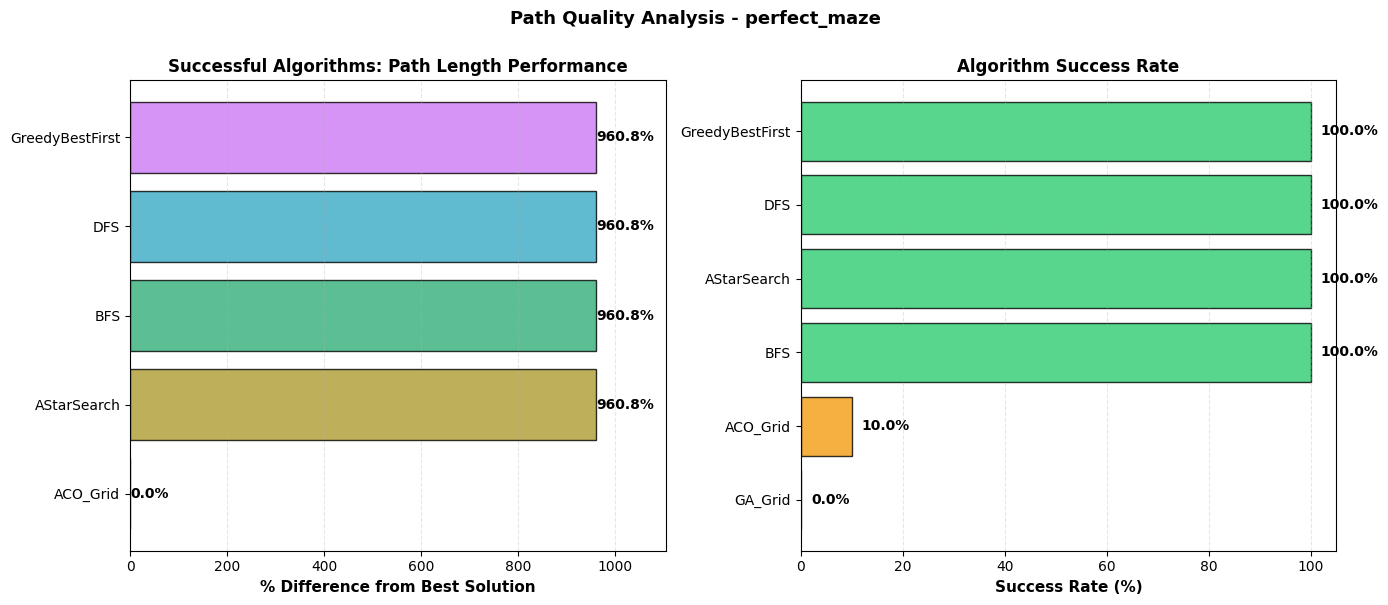

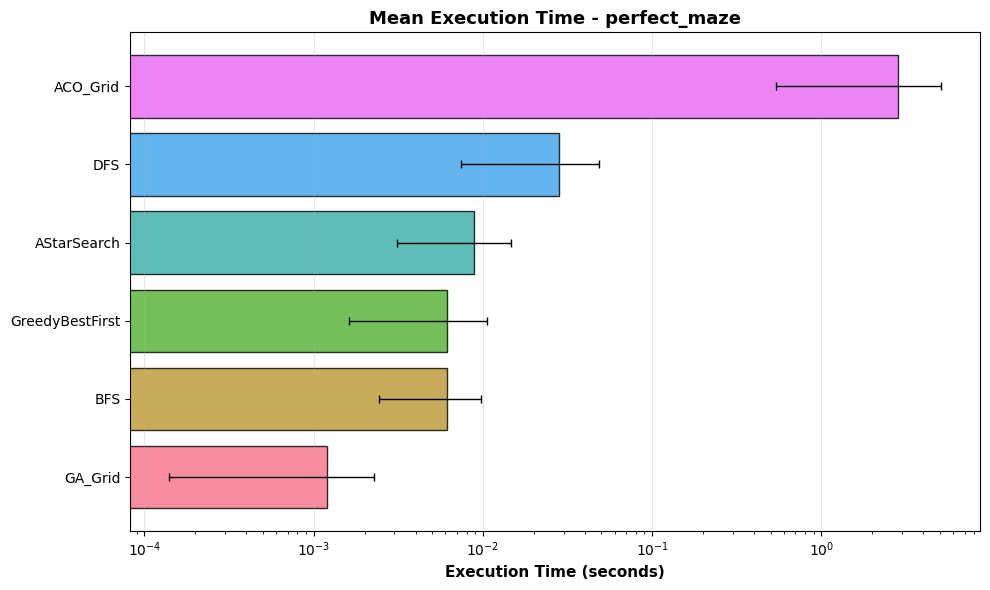

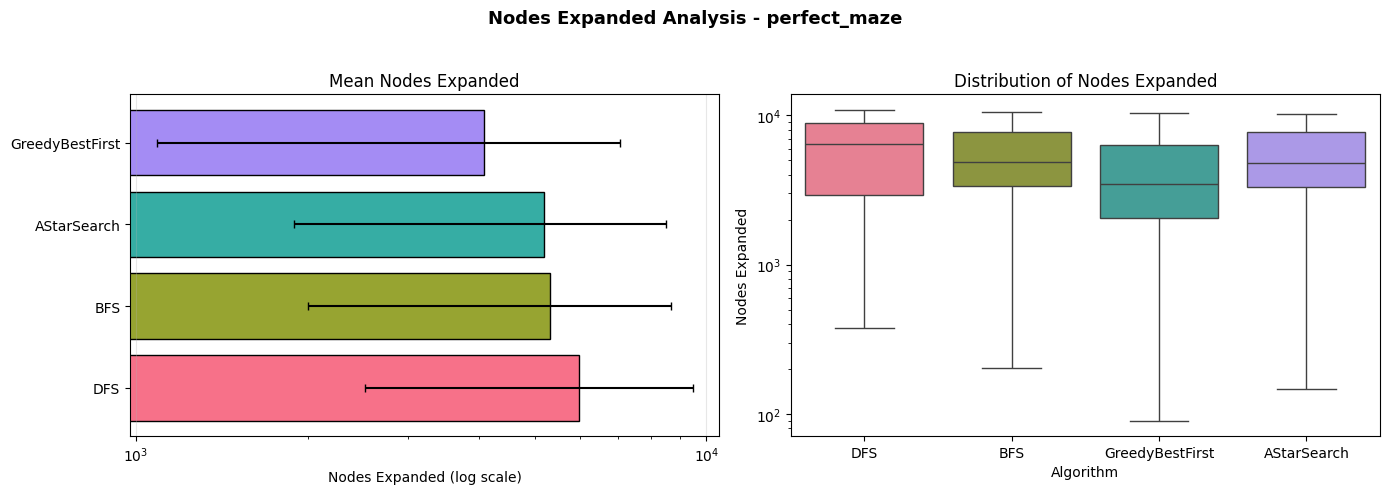


                       PERFECT_MAZE - SUMMARY STATISTICS                        

OVERALL PERFORMANCE:
--------------------------------------------------------------------------------
                 Total Runs  Successful  Mean Path  Best Path  Mean Time  \
algorithm                                                                  
ACO_Grid                 20           2        inf       86.0     2.8232   
AStarSearch              20          20    1617.65       86.0     0.0089   
BFS                      20          20    1617.65       86.0     0.0061   
DFS                      20          20    1617.65       86.0     0.0281   
GA_Grid                  20           0        inf        inf     0.0012   
GreedyBestFirst          20          20    1617.65       86.0     0.0061   

                 Std Time  Success Rate %  
algorithm                                  
ACO_Grid           2.2856            10.0  
AStarSearch        0.0058           100.0  
BFS                0.0037     

In [87]:
case_name = 'perfect_maze'
if case_name in benchmark_results:
    df = benchmark_results[case_name]
    
    fig = analyze_path_quality(df, case_name)
    plt.savefig(OUTPUT_DIR / f'{case_name}_pathlen_performance.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    fig = analyze_execution_time(df, case_name)
    plt.savefig(OUTPUT_DIR / f'{case_name}_execution_time.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    fig = analyze_nodes_expanded(df, case_name)
    plt.savefig(OUTPUT_DIR / f'{case_name}_nodes_expanded.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print_summary_stats(df, case_name)
else:
    print(f"Benchmark data not available for {case_name}")

### maze_loops - Benchmark Results

In [ ]:
case_name = 'maze_loops'
if case_name in benchmark_results:
    df = benchmark_results[case_name]
    
    fig = analyze_path_quality(df, case_name)
    plt.savefig(OUTPUT_DIR / f'{case_name}_pathlen_performance.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    fig = analyze_execution_time(df, case_name)
    plt.savefig(OUTPUT_DIR / f'{case_name}_execution_time.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    fig = analyze_nodes_expanded(df, case_name)
    plt.savefig(OUTPUT_DIR / f'{case_name}_nodes_expanded.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print_summary_stats(df, case_name)
else:
    print(f"Benchmark data not available for {case_name}")

### obstacles - Benchmark Results

In [ ]:
case_name = 'obstacles'
if case_name in benchmark_results:
    df = benchmark_results[case_name]
    
    fig = analyze_path_quality(df, case_name)
    plt.savefig(OUTPUT_DIR / f'{case_name}_pathlen_performance.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    fig = analyze_execution_time(df, case_name)
    plt.savefig(OUTPUT_DIR / f'{case_name}_execution_time.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    fig = analyze_nodes_expanded(df, case_name)
    plt.savefig(OUTPUT_DIR / f'{case_name}_nodes_expanded.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print_summary_stats(df, case_name)
else:
    print(f"Benchmark data not available for {case_name}")

### dense - Benchmark Results

In [ ]:
case_name = 'obstacles_dense'
if case_name in benchmark_results:
    df = benchmark_results[case_name]
    
    fig = analyze_path_quality(df, case_name)
    plt.savefig(OUTPUT_DIR / f'{case_name}_pathlen_performance.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    fig = analyze_execution_time(df, case_name)
    plt.savefig(OUTPUT_DIR / f'{case_name}_execution_time.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    fig = analyze_nodes_expanded(df, case_name)
    plt.savefig(OUTPUT_DIR / f'{case_name}_nodes_expanded.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print_summary_stats(df, case_name)
else:
    print(f"Benchmark data not available for {case_name}")

### perfect_maze - Benchmark Results

In [ ]:
case_name = 'perfect_maze'

if case_name in benchmark_results:
    df = benchmark_results[case_name]

    plt.figure(figsize=(10,6))
    fig = analyze_path_quality(df, case_name)
    plt.savefig(OUTPUT_DIR / f'{case_name}_pathlen_performance.png', dpi=150, bbox_inches='tight')
    plt.show()

    plt.figure(figsize=(10,6))
    fig = analyze_execution_time(df, case_name)
    plt.savefig(OUTPUT_DIR / f'{case_name}_execution_time.png', dpi=150, bbox_inches='tight')
    plt.show()

    plt.figure(figsize=(10,6))
    fig = analyze_nodes_expanded(df, case_name)
    plt.savefig(OUTPUT_DIR / f'{case_name}_nodes_expanded.png', dpi=150, bbox_inches='tight')
    plt.show()

    print_summary_stats(df, case_name)

else:
    print(f"Benchmark data not available for {case_name}")

## Cross-Case Comparison

Compare algorithm performance across all test cases

In [ ]:
# Combine all benchmark results
if benchmark_results:
    all_data = []
    for case_name, df in benchmark_results.items():
        df['case'] = case_name
        all_data.append(df)
    
    combined_df = pd.concat(all_data, ignore_index=True)
    print(f"Combined {len(benchmark_results)} test cases")
    print(f"Total results: {len(combined_df)}")
    
    # Plot comparison across cases
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Path length by case
    case_path_stats = combined_df.groupby(['case', 'algorithm'])['best_fitness'].mean().reset_index()
    for algo in combined_df['algorithm'].unique():
        algo_data = case_path_stats[case_path_stats['algorithm'] == algo]
        axes[0].plot(algo_data['case'], algo_data['best_fitness'], marker='o', label=algo)
    axes[0].set_xlabel('Test Case', fontsize=11, fontweight='bold')
    axes[0].set_ylabel('Mean Path Length', fontsize=11, fontweight='bold')
    axes[0].set_title('Path Length Across Test Cases', fontsize=12, fontweight='bold')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Execution time by case
    case_time_stats = combined_df.groupby(['case', 'algorithm'])['execution_time_seconds'].mean().reset_index()
    for algo in combined_df['algorithm'].unique():
        algo_data = case_time_stats[case_time_stats['algorithm'] == algo]
        axes[1].plot(algo_data['case'], algo_data['execution_time_seconds'], marker='o', label=algo)
    axes[1].set_xlabel('Test Case', fontsize=11, fontweight='bold')
    axes[1].set_ylabel('Mean Execution Time (s)', fontsize=11, fontweight='bold')
    axes[1].set_title('Execution Time Across Test Cases', fontsize=12, fontweight='bold')
    axes[1].set_yscale('log')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    # Nodes expanded by case
    case_nodes_stats = combined_df.groupby(['case', 'algorithm'])['nodes_expanded'].mean().reset_index()
    for algo in combined_df['algorithm'].unique():
        algo_data = case_nodes_stats[case_nodes_stats['algorithm'] == algo]
        axes[2].plot(algo_data['case'], algo_data['nodes_expanded'], marker='o', label=algo)
    axes[2].set_xlabel('Test Case', fontsize=11, fontweight='bold')
    axes[2].set_ylabel('Mean Nodes Expanded', fontsize=11, fontweight='bold')
    axes[2].set_title('Nodes Expanded Across Test Cases', fontsize=12, fontweight='bold')
    axes[2].legend()
    axes[2].grid(alpha=0.3)
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(OUTPUT_DIR / 'cross_case_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

## Summary

This analysis demonstrates:

### Stage 1: Visualization
- Grid structure and obstacle layout for each test case
- Path solutions from 5 different algorithms
- Solution quality and computational metrics

### Stage 2: Benchmark Analysis  
- Path length performance (% difference from best solution)
- Execution time comparison (mean and variance)
- Nodes expanded statistics (search efficiency)
- Cross-case comparison across all 5 test cases

### Key Insights
- **A* Search**: Typically finds optimal or near-optimal paths with efficient search
- **BFS**: Complete and optimal for unweighted graphs, moderate efficiency
- **Greedy Best-First**: Fast but may not find optimal solutions
- **UCS**: Optimal for weighted graphs, more expensive than BFS
- **DFS**: Generally inefficient for pathfinding, explores deeply before backtracking
